# CS-808 Lecture 4 — Data acquisition and data quality
## Why did local apples and imported iPhones both become expensive?
The Rs100→Rs300/kg apple story is an **illustrative observation**, not an official historical series. Our subject is the evidence investigation: claim → source → acquire → audit → analyse → conclude or refuse.

The notebook runs **offline**: every source is read from the saved snapshots in `data/`, and results are written to `outputs/v2/` and `data/v2/derived/`. Source cut-off: **1 October 2026**.

In [ ]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/tools-and-tech-in-data-science/lectures/lecture-04
    os.chdir('/content/teaching/courses/tools-and-tech-in-data-science/lectures/lecture-04')
    !apt-get -qq install -y poppler-utils > /dev/null   # pdftotext
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

In [1]:
from pathlib import Path
import json
import re
import hashlib
import warnings
from email.utils import parsedate_to_datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import urllib3.util.connection as urllib3_connection
from concurrent.futures import ThreadPoolExecutor
import time

warnings.filterwarnings('ignore', category=UserWarning)
urllib3_connection.HAS_IPV6 = False      # some networks stall on IPv6
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 150)

ROOT = Path.cwd()
V2 = ROOT / 'data' / 'v2'
DERIVED = V2 / 'derived'; DERIVED.mkdir(parents=True, exist_ok=True)
OUT = ROOT / 'outputs' / 'v2'; OUT.mkdir(parents=True, exist_ok=True)
RUN_LIVE_DEMO = False
DATA = ROOT / 'data'
HEADERS = {'User-Agent': 'CS808-classroom-demo (dr.farrukh89@gmail.com)'}
INK, TEAL, AMBER, RUST, SLATE = '#12263A', '#1F8A7A', '#F2A541', '#C8553D', '#5B6B7A'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})
PLOTS = OUT / 'plots'; PLOTS.mkdir(parents=True, exist_ok=True)
DIMS = {}
NUM = {}
plt.rcParams.update({'font.size':11,'axes.labelsize':11,'xtick.labelsize':10,'ytick.labelsize':10})
def save(fig, name):
    fig.savefig(PLOTS / f'{name}.png', dpi=200, bbox_inches='tight', facecolor='white')
    from PIL import Image
    DIMS[name] = list(Image.open(PLOTS / f'{name}.png').size)
print('Data folder:', DATA.name, '| everything below runs offline from saved snapshots')

Data folder: data | everything below runs offline from saved snapshots


## 1. Define claims before searching for confirming numbers
Do not ask “which government is to blame?” Ask what policy changed, when, which variable moved and what else changed. Predefine supporting and weakening evidence; an absent suitable measurement is a result.

Four layers stay separate: **reported claim → documented policy/event → observed data → interpretation**.

In [2]:
matrix = pd.DataFrame(json.loads((V2 / 'source_evidence_matrix.json').read_text()))
display(matrix[['claim_id','claim','what_would_support','what_would_weaken','source_type_needed','measurement_period','data_quality_limitations']])


,claim_id,claim,what_would_support,what_would_weaken,source_type_needed,measurement_period,data_quality_limitations
0,I1,Rupee depreciation raised the imported iPhone floor,A larger USD×PKR/USD product at actual availability dates,Comparable source dates show no increase,Apple HTML + SBP exchange rate,"2019, 2021, 2023, 2026 availability dates",Entry tiers change storage; pre-tax benchmark is not observed Pakistan retail
1,I2,An imported iPhone should track the exchange rate alone,Constant USD product price and tax/margin regime,USD price/configuration or domestic additions change,Apple launch price + SBP rate + official taxes,same four launch periods,No constant-quality adjustment or verified current Pakistan tax schedule
2,A1,Apples rose exactly from Rs100/kg to Rs300/kg,"Same variety, market, unit and season over time",Matched apple-specific observations disagree,Apple-specific retail/wholesale price panel,opening observation has unspecified dates,PBS fresh-fruit basket is not apples
3,A2,Local produce is insulated from oil / FX,Input costs and local price data show no exposure,Documented energy / transport / supply movements,PBS CPI/WPI + cost and supply evidence,Jul 2022–Sep 2026,No apple cost accounts; wholesale and retail baskets differ
4,P1,Policy explains the whole inflation rise during PTI period,Identified counterfactual isolates policy from simultaneous shocks,"FX, world prices, COVID and other shocks coincide",Contemporary news + official policy + WB/PBS/SBP,2018–2022; 2023 is after PTI period,Calendar annual values straddle government changes; observational data canno...
5,M1,IMF-linked programme policies contributed through specific channels,Programme clauses + implementation documents + outcomes,Claimed condition absent or not implemented,News + IMF staff report/MEFP + official notifications + CPI,2019 EFF; 2022 review; May 2026 report,Documented commitments differ from implementation and causal estimates
6,F1,Government fuel/subsidy decisions changed administered prices,Dated official old/new prices and effective date,No official change or a different effective date,News + PID notification + IMF review,28 Feb announcement / 1 Mar 2022 effect; June reversal,Direct fuel-price arithmetic does not measure contribution to all CPI
7,S1,COVID and supply disruptions contributed,Dated disruption evidence plus prices and supply measures,Changes predate disruption or no exposure,SBP COVID policy source + commodity data + attributed news,2020–2021,COVID timing and official response documented; apple-specific effect not ide...
8,S2,Floods disrupted domestic food supply,Damage assessment + contemporaneous logistics reporting,Matched unaffected supply/price series,News + joint official PDNA PDF,Jun–Oct 2022 assessment,Assessed aggregate damage is not an apple-price causal coefficient
9,W1,2026 conflict passed through oil→fuel→transport→food,Dated reports + same oil benchmark + policy evidence + CPI timing,No sequential movement or alternative shocks dominate,AP/Axios/Reuters + FRED/EIA + IMF/PBS,"Feb–Sep 2026; feed through Aug, PDF Sep",Event windows descriptive; no counterfactual; separate months and YoY base e...


### Source hierarchy follows the question
News answers who said what and when. IMF/government documents establish commitments and decisions. PBS measures baskets and periods. FRED/EIA measures a specified oil benchmark. Apple and SBP establish inputs for an imported-price benchmark. Apple-specific retail observations would be needed for the exact apple claim. A browser is the final acquisition option when simpler permitted methods do not expose the data.

## 2. Contemporary reporting: public explanations are data
The archive below deliberately samples competing attributions and policy announcements; it is **not a representative opinion survey**. Publication date, event date, speaker and agency are distinct. Full articles are not stored or reproduced. “Individual byline not captured” remains missing metadata, not an invented author.

In [3]:
public = pd.DataFrame(json.loads((V2 / 'public_claims.json').read_text()))
public['publication_date'] = pd.to_datetime(public.publication_date)
assert public.id.is_unique and public.url.is_unique
assert public.publication_date.max() <= pd.Timestamp('2026-10-01')
display(public[['id','claim_id','outlet','publication_date','headline','author','speaker','claim_summary','interpretation_category']])
NUM['public_claims'] = public.assign(publication_date=public.publication_date.dt.strftime('%Y-%m-%d')).to_dict('records')


,id,claim_id,outlet,publication_date,headline,author,speaker,claim_summary,interpretation_category
0,N01,P1,Dawn,2021-11-08,Pakistan fared better than others in managing price hike: PM Imran,Syed Irfan Raza,Imran Khan,PM attributed inflation to global shocks.,reported attribution
1,N02,P1,Express Tribune,2021-11-06,Opposition up in arms against fuel price hike,Saqib Virk / Shabbir Husain,Khawaja Asif; Yousuf Raza Gilani; Shehzad Waseem,Opposition challenged government performance; government speaker pointed to ...,reported attribution
2,N03,M1,Dawn,2019-05-13,$6bn IMF bailout package for Pakistan finalised,Khaleeq Kiani,Abdul Hafeez Shaikh; IMF,"Energy, revenue and exchange-rate commitments reported.",reported policy
3,N04,M1,Express Tribune,2019-07-03,IMF finally approves $6 billion package for Pakistan,Shahbaz Rana,IMF; Finance Ministry; reporter,Reports programme approval and policy commitments; the article also interpre...,reported policy and reporter interpretation
4,N05,F1,Dawn,2022-02-28,"PM Imran slashes petrol prices by Rs10, power tariff by Rs5 as part of relie...",Dawn.com,Imran Khan,Relief announcement reported.,reported announcement
5,N06,F1,RFE/RL,2022-02-28,"Pakistan To Freeze Petrol, Electricity Prices Despite Global Rise",Reuters,Imran Khan,Reports price reductions and promised freeze until the next budget. An annou...,reported announcement
6,N07,M1,Reuters / Investing.com,2022-06-15,Pakistan further removes fuel subsidies to win IMF funding -Finance Minister,Reuters (individual byline unavailable),Miftah Ismail; Finance Ministry,Finance minister linked subsidy removal to IMF support; ministry cited world...,reported policy and attribution
7,N08,M1,Dawn,2022-06-15,Petrol soars to Rs233.89 per litre as govt raises price for third time in 20...,Dawn.com,Miftah Ismail,Subsidy reversal reported.,reported policy
8,N09,S2,Dawn,2022-08-29,Tomato price shoots up to Rs480 a kilo as damaged roads hit supplies,Aamir Shafaat Khan,Haji Shahjehan,Trader linked supply disruption to damaged roads.,reported local observation
9,N10,S2,Reuters / MarketScreener,2022-08-31,Vegetable prices spike in flood-hit Pakistan as food crisis looms,Reuters (individual byline not captured),"Malik Salim Awan, Lahore supplier",Supplier described road and crop damage constraining food supplies. A local ...,reported local observation


### RSS acquisition: a rolling window cannot reconstruct 2019–2022
Replay the saved HTTP/collection log, then parse a saved RSS item. A live collection would check terms and robots, identify its client, pace requests, save the allowed snapshot and stop/back off on refusal. We use archives for historical claims and distinguish their acquisition method from RSS.

In [4]:
log = [json.loads(line) for line in (DATA / 'news' / 'feeds_provenance.jsonl').read_text().splitlines()]
feeds = pd.DataFrame(log)
feeds['feed'] = feeds['feed'].str.replace('https://', '', regex=False).str[:42]
cols = [c for c in ['outlet', 'feed', 'status', 'items', 'oldest', 'newest', 'WARNING', 'error'] if c in feeds.columns]
latest_run = feeds.sort_values('retrieved_utc').groupby('feed').tail(1)
_w = latest_run['WARNING'].dropna().astype(str) if 'WARNING' in latest_run.columns else pd.Series(dtype=str)
NUM['stale_feed_days'] = int(re.search(r'(\d+) days', _w.iloc[0]).group(1)) if len(_w) else None
latest_run[cols].fillna('').assign(oldest=lambda d: d.oldest.astype(str).str[:10], newest=lambda d: d.newest.astype(str).str[:10])

,outlet,feed,status,items,oldest,newest,WARNING,error
0,BBC,feeds.bbci.co.uk/news/world/rss.xml,200,32.0,2026-09-29,2026-10-01,,
2,DW,rss.dw.com/xml/rss-en-all,200,133.0,2026-09-03,2026-10-01,,
3,Al Jazeera,www.aljazeera.com/xml/rss/all.xml,error,,,,,"ConnectionError: ('Connection aborted.', ConnectionResetError(104, 'Connecti..."
4,Dawn,www.dawn.com/feeds/latest-news,200,30.0,2026-10-01,2026-10-01,,
8,Tribune,tribune.com.pk/feed/business,200,25.0,2026-08-18,2026-09-30,,
10,The News,www.thenews.com.pk/rss/1/1,200,50.0,2025-11-16,2025-11-21,stale feed: newest item is 314 days older than the feed's own build date,
5,Dawn,www.dawn.com/feeds/business,200,30.0,2026-09-28,2026-10-01,,
9,Tribune,tribune.com.pk/feed/home,200,74.0,2026-03-06,2026-09-30,,
1,BBC,feeds.bbci.co.uk/news/business/rss.xml,200,39.0,2026-06-30,2026-10-01,,
6,Dawn,www.dawn.com/feeds/pakistan,200,30.0,2026-09-30,2026-10-01,,


In [5]:
g = json.loads((DATA / 'news' / 'first_attempt_provenance.json').read_text())
calls = pd.DataFrame(g['calls'])[['retrieved_utc', 'status', 'attempt']]
calls['retrieved_utc'] = calls['retrieved_utc'].str[11:19]
print('Requests to the GDELT news-archive API (a research service), in order:')
calls.rename(columns={'retrieved_utc': 'time (UTC)'})

Requests to the GDELT news-archive API (a research service), in order:


,time (UTC),status,attempt
0,04:59:46,429,1
1,05:01:39,429,2
2,05:03:58,200,3
3,05:04:27,200,1


In [6]:
import xml.etree.ElementTree as ET
samples = json.loads((DATA / 'feed_samples.json').read_text())
sample = next(x for x in samples if x['outlet'] == 'BBC')
raw_xml = sample['items'][0]['raw_xml']
# The stored sample contains an unbound thumbnail prefix. Remove that element only
# from the parsing copy; retain the original evidence unchanged.
parse_xml = re.sub(r'<ns0:thumbnail\b[^>]*/>', '', raw_xml)
item = ET.fromstring(parse_xml)
fields = {k: item.findtext(k) for k in ['title','link','pubDate','description']}
fields['published_utc'] = parsedate_to_datetime(fields['pubDate']).astimezone(__import__('datetime').timezone.utc).isoformat()
print('GET', sample['feed'], '| saved HTTP', sample['status'], '|', sample['content_type'])
print(raw_xml[:600]); display(pd.Series(fields))


GET https://feeds.bbci.co.uk/news/world/rss.xml | saved HTTP 200 | text/xml; charset=utf-8
<item>
            <title>US death row inmate Christa Pike taken to hospital after surviving two lethal injections, says lawyer</title>
            <description>Her lawyer says Pike is being "provided life-saving measures" after two syringes of pentobarbital.</description>
            <link>https://www.bbc.co.uk/news/articles/cq8r6rjdvlx6o?at_medium=RSS&amp;at_campaign=rss</link>
            <guid isPermaLink="false">https://www.bbc.co.uk/news/articles/cq8r6rjdvlx6o#0</guid>
            <pubDate>Thu, 01 Oct 2026 04:35:26 GMT</pubDate>
            <ns0:thumbnail width="240" height="135" url="ht


title            US death row inmate Christa Pike taken to hospital after surviving two letha...
link             https://www.bbc.co.uk/news/articles/cq8r6rjdvlx6o?at_medium=RSS&at_campaign=rss
pubDate                                                            Thu, 01 Oct 2026 04:35:26 GMT
description      Her lawyer says Pike is being "provided life-saving measures" after two syri...
published_utc                                                          2026-10-01T04:35:26+00:00
dtype: str

In [7]:
news = pd.read_csv(DATA / 'news_snapshot_20261001.csv', parse_dates=['published_utc'])
print('Snapshot:', len(news), 'articles from', news.outlet.nunique(), 'outlets')
news.groupby(['scope', 'outlet']).agg(articles=('title', 'size'), oldest=('published_utc', lambda s: s.min().strftime('%d %b %Y')),
                                     newest=('published_utc', lambda s: s.max().strftime('%d %b %Y')))

Snapshot: 420 articles from 5 outlets


articles       oldest       newest
scope         outlet                                      
international BBC             67  30 Jun 2026  01 Oct 2026
              DW             133  03 Sep 2026  01 Oct 2026
local         Dawn            87  28 Sep 2026  01 Oct 2026
              The News        50  16 Nov 2025  21 Nov 2025
              Tribune         83  06 Mar 2026  30 Sep 2026

In [8]:
news['text'] = (news.title.fillna('') + '. ' + news.summary.fillna('')).str.strip()
q = {
    'duplicate links': int(news.link.duplicated().sum()),
    'duplicate titles': int(news.title.duplicated().sum()),
    'empty summaries': int((news.summary.fillna('') == '').sum()),
    'authors that are placeholders (none@none.com)': int(news.author.fillna('').str.contains('none@none.com').sum()),
    'articles with a published time': int(news.published_utc.notna().sum()),
    'timestamps in UTC (converted from +0500 etc.)': str(news.published_utc.dt.tz),
}
pd.Series(q, name='result')

duplicate links                                    0
duplicate titles                                   0
empty summaries                                    0
authors that are placeholders (none@none.com)     87
articles with a published time                   420
timestamps in UTC (converted from +0500 etc.)    UTC
Name: result, dtype: object

In [9]:
NUM['news_quality'] = q
news_raw = news.copy()


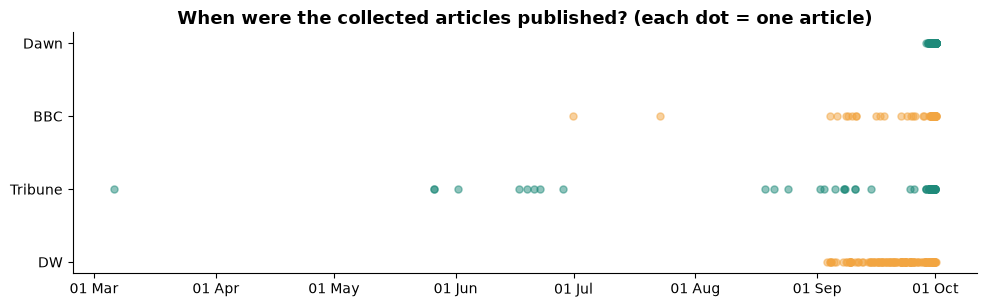

In [10]:
news = news[news.outlet != 'The News'].reset_index(drop=True)      # stale feed removed, and we say so
order = ['Dawn', 'BBC', 'Tribune', 'DW']
fig, ax = plt.subplots(figsize=(10, 3.2))
for k, o in enumerate(order):
    d = news[news.outlet == o].published_utc
    ax.scatter(d, [k] * len(d), s=26, alpha=0.5, color=TEAL if o in ('Dawn', 'Tribune') else AMBER)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_title('When were the collected articles published? (each dot = one article)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); save(fig, 'article_windows'); plt.show()
NUM['by_outlet'] = {k: int(v) for k, v in news.outlet.value_counts().items()}
NUM.update(n_articles=int(len(news)), n_outlets=int(news.outlet.nunique()), n_local=int((news.scope == 'local').sum()), n_intl=int((news.scope == 'international').sum()),
           n_placeholder_authors=int(news.author.fillna('').str.contains('none@none.com').sum()))

In [11]:
archive_audit = {
 'unique URLs': public.url.nunique(), 'duplicate URLs': int(public.url.duplicated().sum()),
 'uncaptured individual bylines': int(public.author.str.contains('not captured|unavailable').sum()),
 'outlets': public.outlet.nunique(), 'original agencies': public.origin_agency.nunique(),
 'selection': 'purposive claim archive; not public opinion or a census of news',
 'September war reports': 'two publishers, same Reuters agency; not independent confirmation',
 'event vs publication': '7 September report describes weekend events; live stories can be updated',
}
display(pd.Series(archive_audit)); NUM['archive_audit']=archive_audit


unique URLs                                                                                            16
duplicate URLs                                                                                          0
uncaptured individual bylines                                                                           7
outlets                                                                                                 8
original agencies                                                                                       5
selection                                 purposive claim archive; not public opinion or a census of news
September war reports                   two publishers, same Reuters agency; not independent confirmation
event vs publication             7 September report describes weekend events; live stories can be updated
dtype: object

**Quality result:** HTTP 200 ≠ current/trustworthy data; a placeholder author ≠ null; missing archive years ≠ a null field. A syndicated story is not independent corroboration. A headline may compress a claim that must be attributed to its speaker. Restrict storage to permitted metadata and short summaries; HTML fallback requires separate permission/terms checks.

## 3. Official structured data, PDFs and provenance
For inflation we need the PBS SDMX feed, not a headline. An index is not a rate or a rupee price. Compare feed coverage with the official monthly PDF before analysing.

In [12]:
pbs_prov = json.loads((DATA / 'pbs_provenance.json').read_text())
feed_rec = next(r for r in pbs_prov if 'pbs_cpi_sdmx' in r['file'])
xml_text = (ROOT / feed_rec['file']).read_text(encoding='utf-8')
print('STEP 1  request :', feed_rec['source_url'])
print('STEP 2  answer  : HTTP', feed_rec['http_status'], '|', feed_rec['bytes'], 'bytes | XML in the SDMX standard')
i = xml_text.find('<Series')
print('STEP 3  the raw data: one series (the general CPI), first observations:\n')
print(re.sub(r'\s+', ' ', xml_text[i:i + 900])[:640] + ' ...')

STEP 1  request : https://www.pbs.gov.pk/cpi/
STEP 2  answer  : HTTP 200 | 80394 bytes | XML in the SDMX standard
STEP 3  the raw data: one series (the general CPI), first observations:

<Series DATA_DOMAIN="CPI" REF_AREA="PK" INDICATOR="PCPI_IX" COUNTERPART_AREA="_Z" FREQ="M" BASE_PER="2015/2016" UNIT_MULT="0"><Obs TIME_PERIOD="2022-07" OBS_VALUE="183.3491269953184"/><Obs TIME_PERIOD="2022-08" OBS_VALUE="187.84009306785492"/><Obs TIME_PERIOD="2022-09" OBS_VALUE="185.6779102036212"/><Obs TIME_PERIOD="2022-10" OBS_VALUE="194.41582943200407"/><Obs TIME_PERIOD="2022-11" OBS_VALUE="195.88902039032095"/><Obs TIME_PERIOD="2022-12" OBS_VALUE="196.85587596593155"/><Obs TIME_PERIOD="2023-01" OBS_VALUE="202.5295360708444"/><Obs TIME_PERIOD="2023-02" OBS_VALUE="211.27810085171188"/><Obs TIME_PERIOD="2023-03" OBS_VALUE="219.138 ...


In [13]:
labels = pd.read_csv(DATA / 'pbs_cpi_monthly.csv').drop_duplicates('indicator').set_index('indicator').label.to_dict()
raw_rows=[]
for series in ET.fromstring(xml_text).iter('Series'):
    indicator=series.attrib['INDICATOR']
    if indicator not in labels: continue  # weight series are not price indices
    assert series.attrib['BASE_PER']=='2015/2016' and series.attrib['UNIT_MULT']=='0'
    for obs in series.iter('Obs'):
        raw_rows.append({'month':obs.attrib['TIME_PERIOD'],'indicator':indicator,'label':labels[indicator],
                         'index_2015_16_100':float(obs.attrib['OBS_VALUE'])})
pbs=pd.DataFrame(raw_rows).sort_values(['indicator','month']).reset_index(drop=True)
reference=pd.read_csv(DATA / 'pbs_cpi_monthly.csv').sort_values(['indicator','month']).reset_index(drop=True)
pd.testing.assert_frame_equal(pbs,reference,check_exact=False,rtol=1e-12)
pbs.to_csv(DERIVED / 'pbs_cpi_monthly.csv',index=False)
print('Reparsed raw SDMX and reconciled with existing tidy data:',pbs.shape)
display(pbs.head())


Reparsed raw SDMX and reconciled with existing tidy data: (650, 4)


,month,indicator,label,index_2015_16_100
0,2022-07,PCPI_CP_01_IX,Food and non-alcoholic beverages,195.274522
1,2022-08,PCPI_CP_01_IX,Food and non-alcoholic beverages,197.809650
2,2022-09,PCPI_CP_01_IX,Food and non-alcoholic beverages,209.212519
3,2022-10,PCPI_CP_01_IX,Food and non-alcoholic beverages,221.004985
4,2022-11,PCPI_CP_01_IX,Food and non-alcoholic beverages,221.140764


In [14]:
# Re-extract PDFs offline, preserving original PDFs and physical page boundaries.
import subprocess
pbs_prov=json.loads((DATA/'pbs_provenance.json').read_text())
for month in ['august','september']:
    rec=next(r for r in pbs_prov if f'review_{month}' in r['file'])
    subprocess.run(['pdftotext','-layout',str(ROOT/rec['file']),str(DERIVED/f'pbs_{month}_2026.txt')],check=True)
rev_aug=(DERIVED/'pbs_august_2026.txt').read_text()
rev_sep=(DERIVED/'pbs_september_2026.txt').read_text()
pat=r'CPI inflation General, increased by ([\d.]+)%'
NUM['cpi_sep_2026']=float(re.search(pat,rev_sep).group(1))
NUM['cpi_aug_2026_text']=float(re.search(pat,rev_aug).group(1))
print('PDF-extracted general YoY:',NUM['cpi_aug_2026_text'],'August;',NUM['cpi_sep_2026'],'September')


PDF-extracted general YoY: 11.1 August; 10.3 September


In [15]:
wide = pbs.pivot(index='month', columns='label', values='index_2015_16_100')
months = pd.period_range(wide.index.min(), wide.index.max(), freq='M')
checks = {
    'series (general + 12 spending groups)': wide.shape[1],
    'months in the feed': f"{wide.index.min()} to {wide.index.max()} ({len(wide)} months)",
    'completeness: months missing inside the range': int(len(months) - len(wide)),
    'completeness: blank index values': int(wide.isna().sum().sum()),
    'uniqueness: duplicated month x series rows': int(pbs.duplicated(['month', 'label']).sum()),
    'validity: index values <= 0': int((pbs.index_2015_16_100 <= 0).sum()),
    'consistency: what the numbers are': 'an index, 2015-16 = 100 (not a % change, not rupees)',
    'timeliness: newest month in the feed': wide.index.max() + '  (the PDF review already has September)',
}
NUM['pbs_months'] = int(len(wide))
NUM['pbs_audit'] = {'series': int(wide.shape[1]), 'missing_months': checks['completeness: months missing inside the range'], 'blank': checks['completeness: blank index values'],
                    'duplicates': checks['uniqueness: duplicated month x series rows'], 'non_positive': checks['validity: index values <= 0'], 'newest': wide.index.max()}
wide_dt = wide.copy(); wide_dt.index = pd.to_datetime(wide.index + '-01')
pd.Series(checks, name='result')

series (general + 12 spending groups)                                                              13
months in the feed                                                     2022-07 to 2026-08 (50 months)
completeness: months missing inside the range                                                       0
completeness: blank index values                                                                    0
uniqueness: duplicated month x series rows                                                          0
validity: index values <= 0                                                                         0
consistency: what the numbers are                an index, 2015-16 = 100 (not a % change, not rupees)
timeliness: newest month in the feed                  2026-08  (the PDF review already has September)
Name: result, dtype: object

### Feed lag is a missing-row problem
The SDMX feed ends in August while the September PDF has newer observations. Do not silently insert one PDF headline into a complete multi-category feed. Preserve each source/vintage; use the PDF only for explicitly labelled September facts.

Raw = acquired evidence; interim = extracted/parsed tables; derived = transformations/figures/findings. A checksum detects file changes; it does **not** prove factual truth.

In [16]:
prov = json.loads((DATA / 'provenance.json').read_text())
def prov_rec(key): return next(r for r in prov if key in r['file'])
def wb_series(key):
    rows = json.loads((ROOT / prov_rec(key)['file']).read_text())[1]
    return {int(x['date']): x['value'] for x in rows if x['value'] is not None}
wb_infl, wb_fx = wb_series('worldbank_pk_inflation'), wb_series('worldbank_pk_pkr_per_usd')
imf_vals = json.loads((ROOT / prov_rec('imf_datamapper')['file']).read_text())['values']['PCPIPCH']['PAK']
brent_d = pd.read_csv(ROOT / prov_rec('fred_brent')['file']); brent_d.columns = ['date', 'usd']
brent_d['date'] = pd.to_datetime(brent_d['date']); brent_d['usd'] = pd.to_numeric(brent_d['usd'], errors='coerce')
brent_d = brent_d.dropna().set_index('date').usd

annual = pd.DataFrame({'inflation_pct': pd.Series(wb_infl), 'pkr_per_usd': pd.Series(wb_fx),
                       'brent_usd': brent_d.groupby(brent_d.index.year).mean()}).loc[2014:2025].copy()
display(annual.loc[2018:2025].round(2))

,inflation_pct,pkr_per_usd,brent_usd
2018,5.08,121.82,71.33
2019,10.58,150.04,64.30
2020,9.74,161.84,41.96
2021,9.50,162.91,70.86
2022,19.87,204.87,100.93
2023,30.77,280.36,82.49
2024,12.63,278.58,80.52
2025,3.55,281.14,69.14


In [17]:
brent_rec=prov_rec('fred_brent')
all_recs=prov+pbs_prov+[json.loads((DATA/'imf_provenance.json').read_text())]+json.loads((V2/'provenance.json').read_text())+json.loads((V2/'iphone_sources.json').read_text())['files']
checksums=[]
for rec in all_recs:
    path=ROOT/rec['file'];actual=hashlib.sha256(path.read_bytes()).hexdigest()
    checksums.append({'file':rec['file'],'matches':actual==rec['sha256'],'representation':rec.get('representation',rec.get('note','see source manifest'))})
assert all(r['matches'] for r in checksums)
display(pd.DataFrame(checksums))
NUM['checksum_files']=len(checksums)


,file,matches,representation
0,data/raw/fred_brent_daily_usd_20261001T100927Z.csv,True,"FRED series DCOILBRENTEU (U.S. EIA data): Europe Brent spot price FOB, USD p..."
1,data/raw/worldbank_pk_inflation_annual_20261001T100931Z.json,True,"World Bank FP.CPI.TOTL.ZG: inflation, consumer prices (annual %), Pakistan, ..."
2,data/raw/worldbank_pk_pkr_per_usd_annual_20261001T100935Z.json,True,"World Bank PA.NUS.FCRF: official exchange rate (PKR per USD, period average)..."
3,data/raw/imf_datamapper_pak_inflation_20261001T100940Z.json,True,"IMF DataMapper: inflation, average consumer prices (annual % change), Pakist..."
4,data/raw/books_toscrape_pages1-3_20261001T100944Z.json,True,3 pages parsed with BeautifulSoup; practice site.
5,data/raw/pbs_cpi_sdmx_20261001T100949Z.xml,True,"SDMX-ML structure-specific data: monthly CPI (base 2015-16 = 100), general a..."
6,data/raw/pbs_monthly_review_august_2026_20261001T100957Z.pdf,True,PBS Monthly Review on Price Indices (PDF)
7,data/raw/pbs_monthly_review_september_2026_20261001T101009Z.pdf,True,PBS Monthly Review on Price Indices (PDF)
8,data/raw/imf_cr26101_20261001T101351Z.pdf,True,"IMF Country Report 26/101. Third review, EFF; second review, RSF. Board date..."
9,data/v2/raw/imf_2022_report_20261001.pdf,True,original HTTP response body


### Six questions, applied after each acquisition
| Dimension | Evidence question |
|---|---|
| Completeness | Which expected rows/keys and values are absent? |
| Validity | Are units, ranges, types and semantics right? |
| Uniqueness | Are links, keys or syndicated stories repeated? |
| Consistency | Same definition, period, source vintage and configuration? |
| Timeliness | How recent is the observation, not just the response? |
| Representativeness | Does this basket/sample measure our intended population/item? |

## 4. Historical context, 2018–2026
Annual World Bank inflation and exchange-rate averages are matched to calendar years. These are **not** launch-day rates. 2026 data are partial and shown separately. Political periods do not align perfectly with calendar-year observations. Event markers are context, not causal estimates.

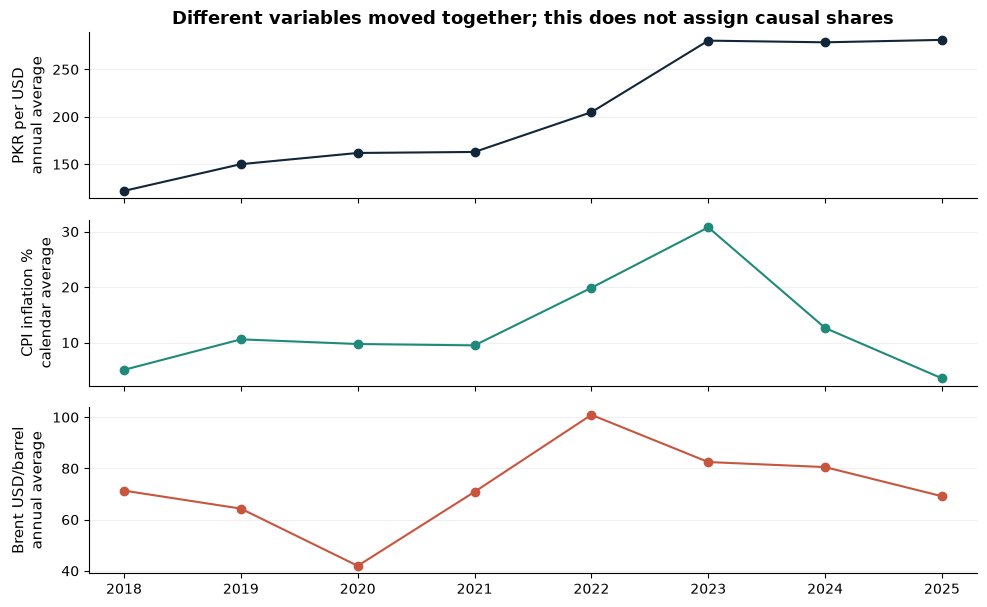

,inflation_pct,pkr_per_usd,brent_usd,rise_in_pkr_per_usd_pct
2018,5.08,121.82,71.33,NaN
2019,10.58,150.04,64.30,23.16
2020,9.74,161.84,41.96,7.87
2021,9.50,162.91,70.86,0.66
2022,19.87,204.87,100.93,25.76
2023,30.77,280.36,82.49,36.85
2024,12.63,278.58,80.52,-0.63
2025,3.55,281.14,69.14,0.92


In [18]:
history=annual.loc[2018:2025,['inflation_pct','pkr_per_usd','brent_usd']].copy()
history['rise_in_pkr_per_usd_pct']=history.pkr_per_usd.pct_change()*100
history.to_csv(DERIVED/'historical_context.csv')
fig,axs=plt.subplots(3,1,figsize=(10,6.2),sharex=True)
for ax,col,label,color in zip(axs,['pkr_per_usd','inflation_pct','brent_usd'],['PKR per USD\nannual average','CPI inflation %\ncalendar average','Brent USD/barrel\nannual average'],[INK,TEAL,RUST]):
 ax.plot(history.index,history[col],marker='o',color=color);ax.set_ylabel(label)
 ax.set_xlim(2017.7,2025.3);ax.grid(axis='y',alpha=.18)
axs[0].set_title('Different variables moved together; this does not assign causal shares')
axs[-1].set_xticks(history.index);plt.tight_layout();save(fig,'historical_context');plt.show()
NUM['history']=history.round(3).reset_index(names='year').to_dict('records')
NUM['historical_change']={c:float(100*(history.loc[2022,c]/history.loc[2018,c]-1)) for c in ['pkr_per_usd','brent_usd']}
display(history.round(2))


In [19]:
events=[
 {'year':'2018','event':'PTI government period begins (August)','source':'https://na.gov.pk/en/priminister_list.php','role':'official prime-minister term, not attribution'},
 {'year':'2019','event':'3 Jul: 39-month EFF approved, about US$6bn','source':'https://www.imf.org/en/news/articles/2019/07/03/pr19264-pakistan-imf-executive-board-approves-39-month-eff-arrangement','role':'official programme'},
 {'year':'2020','event':'Mar–Jun: COVID response; SBP rate cuts','source':'https://www.sbp.org.pk/our-operations/covid-19-measures-by-sbp/','role':'official pandemic response'},
 {'year':'2021','event':'Nov: competing public inflation explanations','source':'https://tribune.com.pk/story/2328116/opposition-up-in-arms-against-fuel-price-hike','role':'reported attribution'},
 {'year':'2022','event':'1 Mar fuel cut; 10 Apr no-confidence; Jun subsidy reversal; floods','source':'PID PR255; NA 10 Apr minutes; IMF CR22/288 MEFP; joint PDNA','role':'separate dated official records'},
 {'year':'2023','event':'12 Jul: nine-month SBA, about US$3bn','source':'https://www.imf.org/en/news/articles/2023/07/12/pr23261-pakistan-imf-exec-board-approves-us3bil-sba','role':'official programme'},
 {'year':'2024','event':'25 Sep: 37-month EFF approved, about US$7bn (release 27 Sep)','source':'https://www.imf.org/en/news/articles/2024/09/27/pr-24343-pakistan-imf-concludes-2024-aiv-consultation-pakistan-approves-37-mo-extended-arr','role':'official programme'},
 {'year':'2025','event':'Low inflation in the observed PBS monthly window','source':'PBS SDMX; computed below','role':'observed data, not a policy verdict'},
 {'year':'2026','event':'28 Feb conflict; 7 Mar/3 Apr fuel changes; Sep Apple launch','source':'N11/N12; IMF CR26/101; Apple Newsroom 9 Sep','role':'partial year; events are context'}]
NUM['timeline']=events;display(pd.DataFrame(events))


,year,event,source,role
0,2018,PTI government period begins (August),https://na.gov.pk/en/priminister_list.php,"official prime-minister term, not attribution"
1,2019,"3 Jul: 39-month EFF approved, about US$6bn",https://www.imf.org/en/news/articles/2019/07/03/pr19264-pakistan-imf-executi...,official programme
2,2020,Mar–Jun: COVID response; SBP rate cuts,https://www.sbp.org.pk/our-operations/covid-19-measures-by-sbp/,official pandemic response
3,2021,Nov: competing public inflation explanations,https://tribune.com.pk/story/2328116/opposition-up-in-arms-against-fuel-pric...,reported attribution
4,2022,1 Mar fuel cut; 10 Apr no-confidence; Jun subsidy reversal; floods,PID PR255; NA 10 Apr minutes; IMF CR22/288 MEFP; joint PDNA,separate dated official records
5,2023,"12 Jul: nine-month SBA, about US$3bn",https://www.imf.org/en/news/articles/2023/07/12/pr23261-pakistan-imf-exec-bo...,official programme
6,2024,"25 Sep: 37-month EFF approved, about US$7bn (release 27 Sep)",https://www.imf.org/en/news/articles/2024/09/27/pr-24343-pakistan-imf-conclu...,official programme
7,2025,Low inflation in the observed PBS monthly window,PBS SDMX; computed below,"observed data, not a policy verdict"
8,2026,28 Feb conflict; 7 Mar/3 Apr fuel changes; Sep Apple launch,N11/N12; IMF CR26/101; Apple Newsroom 9 Sep,partial year; events are context


### The PTI question, stated directly
How much of the 2018–2022 price rise can be attributed to policy, and how much coincided with exchange-rate, global, COVID and other shocks? Reporting records blame and defence; official records establish specific decisions. This annual observational comparison does **not** identify a counterfactual or a political blame percentage. 2023 inflation is not labelled as a PTI-government observation.

## 5. Imported iPhone: acquire each input, then calculate
Apple Newsroom confirms actual US starting prices and availability dates. SBP USD READY mark-to-market weighted closing interbank rates match **each US availability date**. No annual averages or arbitrary later-year rates. The latest verified entry is iPhone 18 Pro Max (2026).

Base tiers are 64GB → 128GB → 256GB → 256GB: a product-family entry-price comparison, **not constant storage/quality**. Direct SBP downloads were refused (403); the saved official indexed/extracted captures are labelled as captures rather than original PDFs.

,year,model,storage_gb,availability_date,usd,pkr_per_usd,pkr_floor
0,2019,iPhone 11 Pro Max,64,2019-09-20,1099,156.0798,171531.70
1,2021,iPhone 13 Pro Max,128,2021-09-24,1099,169.0810,185820.02
2,2023,iPhone 15 Pro Max,256,2023-09-22,1199,291.7629,349823.72
3,2026,iPhone 18 Pro Max,256,2026-09-18,1299,277.2522,360150.61


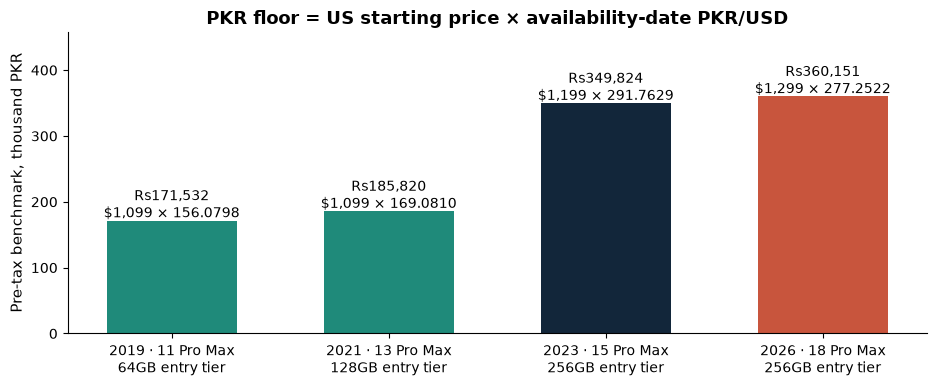

2019→2026: US base price +18.2%; PKR/USD +77.6%; pre-tax floor +110.0%. 2023→2026 floor +3.0% despite a lower PKR/USD rate.
Mechanical pre-tax benchmark, not Pakistan retail or verified current PTA/FBR tax. Entry storage changes; no constant-quality interpretation.


In [20]:
from iphone_evidence_v2 import load_iphone_inputs
iphone=load_iphone_inputs(ROOT)
iphone['pkr_floor']=iphone.usd*iphone.pkr_per_usd
iphone.to_csv(DERIVED/'iphone_launch_comparison.csv',index=False)
base=iphone.iloc[0];latest=iphone.iloc[-1];previous=iphone.iloc[-2]
changes={k:float(100*(latest[k]/base[k]-1)) for k in ['usd','pkr_per_usd','pkr_floor']}
recent={k:float(100*(latest[k]/previous[k]-1)) for k in ['usd','pkr_per_usd','pkr_floor']}
NUM['iphone']={'rows':iphone.to_dict('records'),'changes_2019_2026':changes,'changes_2023_2026':recent,
 'methodology':json.loads((V2/'iphone_sources.json').read_text())['methodology'],
 'conclusion':f"2019→2026: US base price +{changes['usd']:.1f}%; PKR/USD +{changes['pkr_per_usd']:.1f}%; pre-tax floor +{changes['pkr_floor']:.1f}%. 2023→2026 floor +{recent['pkr_floor']:.1f}% despite a lower PKR/USD rate.",
 'limit':'Mechanical pre-tax benchmark, not Pakistan retail or verified current PTA/FBR tax. Entry storage changes; no constant-quality interpretation.'}
display(iphone[['year','model','storage_gb','availability_date','usd','pkr_per_usd','pkr_floor']].round({'pkr_per_usd':4,'pkr_floor':2}))
fig,ax=plt.subplots(figsize=(9.5,4))
ax.bar(iphone.year.astype(str),iphone.pkr_floor/1000,color=[TEAL,TEAL,INK,RUST],width=.6)
for i,r in iphone.iterrows():ax.text(i,r.pkr_floor/1000+5,f"Rs{r.pkr_floor:,.0f}\n${r.usd:,} × {r.pkr_per_usd:.4f}",ha='center',fontsize=10)
ax.set_ylim(0,iphone.pkr_floor.max()/1000*1.27);ax.set_ylabel('Pre-tax benchmark, thousand PKR');ax.set_title('PKR floor = US starting price × availability-date PKR/USD')
ax.set_xticks(range(len(iphone)));ax.set_xticklabels([f'{r.year} · {r.model.replace("iPhone ","")}\n{r.storage_gb}GB entry tier' for _,r in iphone.iterrows()])
plt.tight_layout();save(fig,'iphone_floor');plt.show()
print(NUM['iphone']['conclusion']);print(NUM['iphone']['limit'])


The inputs multiply; their percentage changes do not add. We do not assign causal shares. Domestic duties/taxes, freight and margins are separate additions and may vary. We cannot verify the exact current Pakistani addition with the sources collected, so it does not enter the verdict.

## 6. Locally grown apples: the measurement boundary matters
A fresh-fruit basket is not an apple series. General/food/transport/energy indices show price movements in broad categories, not the cost accounts of an apple grower, store or retailer.

In [21]:
b = pd.read_csv(ROOT / brent_rec['file'])
b.columns = ['date', 'usd_per_barrel']
b['date'] = pd.to_datetime(b['date'])
b['usd_per_barrel'] = pd.to_numeric(b['usd_per_barrel'], errors='coerce')
retrieved = pd.to_datetime(brent_rec['retrieved_utc'], format='%Y%m%dT%H%M%SZ').normalize()
last_obs = b.dropna().date.max()

checks = {
    'rows': len(b),
    'first / last date': f"{b.date.min():%Y-%m-%d} / {b.date.max():%Y-%m-%d}",
    'uniqueness: duplicate dates': int(b.date.duplicated().sum()),
    'completeness: missing prices': int(b.usd_per_barrel.isna().sum()),
    'completeness: missing in 2026': int(b[b.date >= '2026-01-01'].usd_per_barrel.isna().sum()),
    'validity: prices <= 0': int((b.usd_per_barrel <= 0).sum()),
    'validity: weekend rows': int((b.date.dt.weekday >= 5).sum()),
    'timeliness: days between last price and download': int((retrieved - last_obs).days),
    'consistency: unit': 'USD per barrel (not PKR, not per litre)',
}
NUM['brent_audit'] = {'rows': int(len(b)), 'missing': int(b.usd_per_barrel.isna().sum()), 'missing_2026': int(b[b.date >= '2026-01-01'].usd_per_barrel.isna().sum()),
                      'lag_days': int((retrieved - last_obs).days), 'first': f'{b.date.min():%Y-%m-%d}', 'last': f'{last_obs:%Y-%m-%d}',
                      'duplicates': checks['uniqueness: duplicate dates'], 'non_positive': checks['validity: prices <= 0'], 'weekend_rows': checks['validity: weekend rows']}
pd.Series(checks, name='result')

rows                                                                                  10270
first / last date                                                   1987-05-20 / 2026-09-29
uniqueness: duplicate dates                                                               0
completeness: missing prices                                                           1173
completeness: missing in 2026                                                             6
validity: prices <= 0                                                                     0
validity: weekend rows                                                                    0
timeliness: days between last price and download                                          2
consistency: unit                                   USD per barrel (not PKR, not per litre)
Name: result, dtype: object

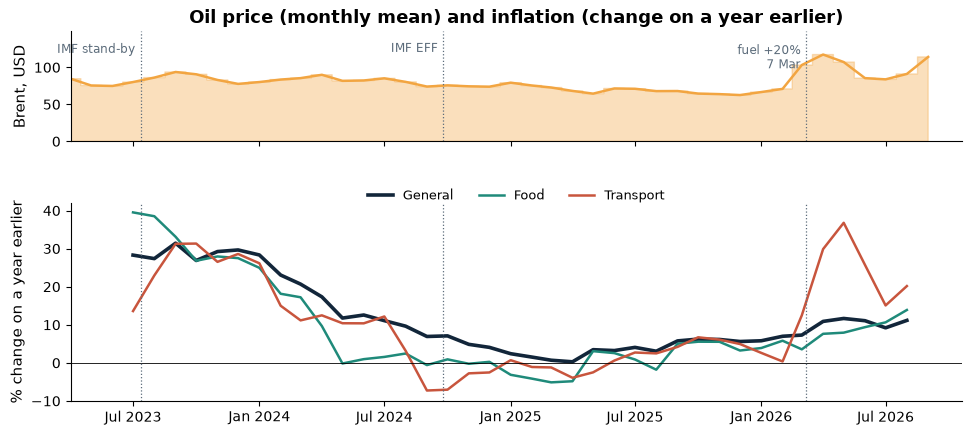

{'general_peak': 31.4, 'general_peak_month': 'Sep 2023', 'general_low': 0.3, 'general_low_month': 'Apr 2025', 'general_feb26': 7.0, 'general_apr26': 10.9, 'general_aug26': 11.2, 'transport_dec25': 4.9, 'transport_feb26': 0.4, 'transport_mar26': 12.5, 'transport_apr26': 29.9, 'transport_may26': 36.8, 'transport_aug26': 20.2, 'food_dec25': 3.2, 'food_aug26': 13.9}


In [22]:
yoy = (wide_dt / wide_dt.shift(12) - 1) * 100
bm = b.dropna().set_index('date').usd_per_barrel.resample('MS').mean()
fig, axs = plt.subplots(2, 1, figsize=(11.5, 4.8), sharex=True, gridspec_kw={'height_ratios': [1, 1.8], 'hspace':0.4})
axs[0].fill_between(bm.index, bm.values, color=AMBER, alpha=0.35, step='mid'); axs[0].plot(bm.index, bm.values, color=AMBER, lw=1.8)
axs[0].set_ylabel('Brent, USD'); axs[0].set_ylim(0, max(140, float(bm.max())*1.12)); axs[0].set_title('Oil price (monthly mean) and inflation (change on a year earlier)')
for col, colour, lw in [('General', INK, 2.6), ('Food and non-alcoholic beverages', TEAL, 1.8), ('Transport', RUST, 1.8)]:
    axs[1].plot(yoy.index, yoy[col], color=colour, lw=lw, label=col.replace(' and non-alcoholic beverages', ''))
axs[1].legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5,1.13), fontsize=9); axs[1].set_ylabel('% change on a year earlier'); axs[1].axhline(0, color='k', lw=0.6)
for d, lab in [('2023-07-12', 'IMF stand-by'), ('2024-09-25', 'IMF EFF'), ('2026-03-07', 'fuel +20%')]:
    for ax in axs: ax.axvline(pd.Timestamp(d), color=SLATE, ls=':', lw=0.9)
    axs[0].text(pd.Timestamp(d) + pd.Timedelta(days=-8), 133, lab + ('\n7 Mar' if 'fuel' in lab else ''), fontsize=8.5, color=SLATE, ha='right', va='top')
lo = float(np.floor(yoy[['General', 'Food and non-alcoholic beverages', 'Transport']].min().min() / 5) * 5)
axs[1].set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2026-10-20')); axs[1].set_ylim(lo, 42)
axs[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])); axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); save(fig, 'monthly_inflation_vs_brent'); plt.show()
gi = yoy['General']
NUM['yoy'] = dict(general_peak=round(float(gi.max()), 1), general_peak_month=gi.idxmax().strftime('%b %Y'), general_low=round(float(gi.min()), 1), general_low_month=gi.idxmin().strftime('%b %Y'),
                  general_feb26=round(float(gi['2026-02-01']), 1), general_apr26=round(float(gi['2026-04-01']), 1), general_aug26=round(float(gi['2026-08-01']), 1),
                  transport_dec25=round(float(yoy.Transport['2025-12-01']), 1), transport_feb26=round(float(yoy.Transport['2026-02-01']), 1), transport_mar26=round(float(yoy.Transport['2026-03-01']), 1),
                  transport_apr26=round(float(yoy.Transport['2026-04-01']), 1), transport_may26=round(float(yoy.Transport['2026-05-01']), 1), transport_aug26=round(float(yoy.Transport['2026-08-01']), 1),
                  food_dec25=round(float(yoy['Food and non-alcoholic beverages']['2025-12-01']), 1), food_aug26=round(float(yoy['Food and non-alcoholic beverages']['2026-08-01']), 1))
print({k: v for k, v in NUM['yoy'].items()})

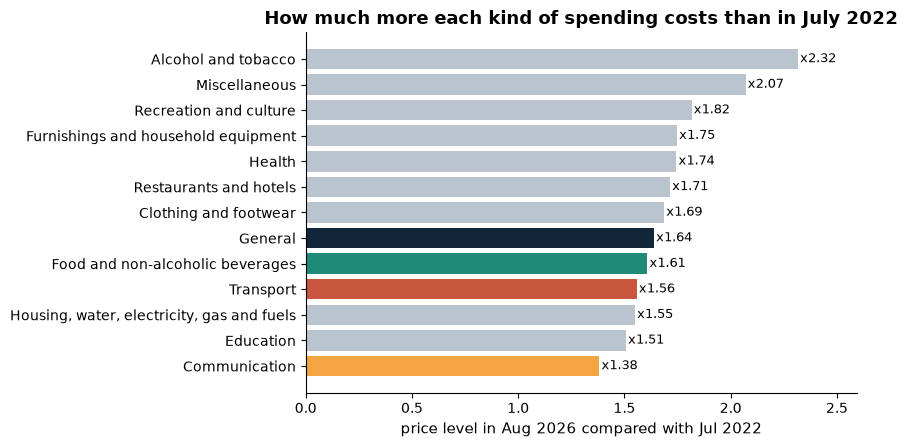

{'Communication': 1.38, 'Transport': 1.56, 'Food and non-alcoholic beverages': 1.61, 'General': 1.64}


In [23]:
rise = (wide_dt.iloc[-1] / wide_dt.iloc[0]).sort_values()
fig, ax = plt.subplots(figsize=(8.8, 4.6))
cols = [RUST if k in ('Transport',) else TEAL if k.startswith('Food') else AMBER if k == 'Communication' else INK if k == 'General' else '#B9C4CE' for k in rise.index]
ax.barh([k[:44] for k in rise.index], rise.values, color=cols)
for i, v in enumerate(rise.values): ax.text(v + 0.01, i, f'x{v:.2f}', va='center', fontsize=9)
ax.set_xlim(0, rise.max() * 1.12); ax.set_xlabel('price level in Aug 2026 compared with Jul 2022'); ax.set_title('How much more each kind of spending costs than in July 2022')
plt.tight_layout(); save(fig, 'divisions_rise'); plt.show()
NUM['divisions'] = {k: round(float(v), 2) for k, v in rise.items()}
print({k: round(float(v), 2) for k, v in rise.items() if k in ('General', 'Transport', 'Communication') or k.startswith('Food')})

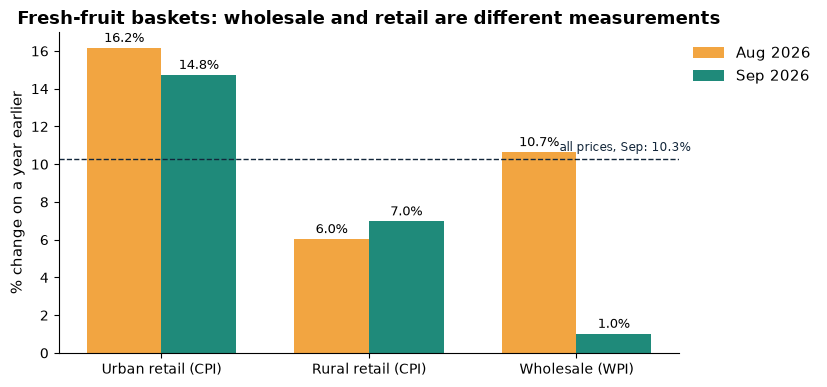

,month,layer,table weight,index now,month on month %,year on year %
0,Aug 2026,Urban retail (CPI),1.44,253.85,-12.49,16.18
1,Aug 2026,Rural retail (CPI),1.45,251.77,-18.76,6.05
2,Aug 2026,Wholesale (WPI),1.51,297.51,-5.51,10.66
3,Sep 2026,Urban retail (CPI),1.44,253.04,-0.32,14.75
4,Sep 2026,Rural retail (CPI),1.45,245.32,-2.56,6.99
5,Sep 2026,Wholesale (WPI),1.51,272.33,-8.46,1.03


In [24]:
def fruit_rows(text, month):
    pat = re.compile(r'(?im)^\s*(\d+)\s+fresh fruits\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([+-])\s*([\d.]+)\s+([+-])\s*([\d.]+)')
    layers = ['Urban retail (CPI)', 'Rural retail (CPI)', 'Wholesale (WPI)']
    ms = list(pat.finditer(text))
    out = []
    for layer, m in zip(layers, ms):
        sgn = lambda s, v: float(v) * (1 if s == '+' else -1)
        out.append({'month': month, 'layer': layer, 'table weight': float(m.group(2)), 'index now': float(m.group(3)),
                    'month on month %': sgn(m.group(6), m.group(7)), 'year on year %': sgn(m.group(8), m.group(9))})
    return out
fruit = pd.DataFrame(fruit_rows(rev_aug, 'Aug 2026') + fruit_rows(rev_sep, 'Sep 2026'))
yoy_part = rev_sep[rev_sep.index('YEAR-ON-YEAR'):]
m_el = re.search(r'Electricity Charges \(([\d.]+)%\)', yoy_part)
m_tr = re.search(r'Transport\s+[\d.]+\s+[\d.]+\s+[\d.]+\s+[\d.]+\s+[\d.]+\s+([\d.]+)', rev_sep)
NUM['pbs_text'] = {'electricity_yoy_sep': float(m_el.group(1)) if m_el else None, 'transport_yoy_sep': float(m_tr.group(1)) if m_tr else None}
NUM['fruit'] = {m: {r.layer: r['year on year %'] for _, r in fruit[fruit.month == m].iterrows()} for m in ['Aug 2026', 'Sep 2026']}
fig, ax = plt.subplots(figsize=(8.4, 4.0))
layers = fruit.layer.unique(); xs = np.arange(len(layers)); w = 0.36
for k, (m, colour) in enumerate([('Aug 2026', AMBER), ('Sep 2026', TEAL)]):
    vals = [float(fruit[(fruit.month == m) & (fruit.layer == l)]['year on year %'].iloc[0]) for l in layers]
    ax.bar(xs + (k - 0.5) * w, vals, w, color=colour, label=m)
    for xx, v in zip(xs + (k - 0.5) * w, vals): ax.text(xx, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.axhline(NUM['cpi_sep_2026'], color=INK, ls='--', lw=1); ax.text(2.55, NUM['cpi_sep_2026'] + 0.4, f"all prices, Sep: {NUM['cpi_sep_2026']}%", fontsize=8.5, ha='right', color=INK)
ax.set_xticks(xs); ax.set_xticklabels(layers); ax.set_ylabel('% change on a year earlier'); ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
ax.set_title('Fresh-fruit baskets: wholesale and retail are different measurements'); plt.tight_layout(); save(fig, 'fresh_fruit_layers'); plt.show()
fruit.round(2)

In [25]:
assert len(fruit)==6 and fruit.groupby('month').size().eq(3).all()
# Explicit scope check: these rows never become an apple-specific series.
fruit.to_csv(DERIVED/'fresh_fruit_layers.csv',index=False)
print('Refused claim: these six basket observations prove apples rose exactly threefold.')


Refused claim: these six basket observations prove apples rose exactly threefold.


Retail and wholesale fresh-fruit changes differ, but basket composition/coverage and weights also differ. Their difference cannot by itself identify retail margins. Electricity and transport movements are consistent with possible downstream costs; a price index cannot reveal their apple-specific contribution.

In [26]:
pdna=(V2/'flood_pdna_2022_text.txt').read_text()
# Physical PDF page locators, not printed page labels.
NUM['flood_pages']={}
for key,pattern in [('scope','94 calamity'),('food_supply','transport infrastructure critical for supplying agriculture'),('damage','agriculture, food, livestock, and fisheries at PKR 800')]:
 hits=[i for i,pg in enumerate(pdna.split('\f'),1) if pattern.lower() in re.sub(r'\s+',' ',pg).lower()]
 assert hits,key;NUM['flood_pages'][key]=hits
print('PDNA physical page locators:',NUM['flood_pages'])
print('Finding: joint assessment documents agriculture and transport damage in affected areas; no apple-specific retail price effect is identified.')


PDNA physical page locators: {'scope': [7, 24, 27, 53], 'food_supply': [42], 'damage': [16]}
Finding: joint assessment documents agriculture and transport damage in affected areas; no apple-specific retail price effect is identified.


## 7. IMF / government policy: test specific channels
Acquire the document, distinguish staff analysis from the authorities’ memorandum, locate the passage and then check implementation. The question is broader than whether the IMF literally chooses a levy number.

In [27]:
policy_text=(V2/'imf_2022_report_text.txt').read_text()
policy_pages=[re.sub(r'\s+',' ',p) for p in policy_text.split('\f')]
channels=[
 ('Subsidy reversal','We removed all post-tax fuel subsidies','Authorities’ MEFP ¶8(a): reports June 2022 fuel and blanket power subsidy reversal'),
 ('Oil-price pass-through','fully passing through international oil price changes','Staff report fiscal policy section: commitment to pass international oil changes through'),
 ('Energy tariffs','regular tariff adjustments','Staff analysis + MEFP: tariff adjustment / cost recovery with protected consumers'),
 ('Exchange-rate regime','market-determined exchange rate','Programme policy: market-determined rate; no fixed rupee value is specified'),
 ('Revenue / levy','PDL','Revenue commitments include fuel taxation; distinguish target, law, notification and effective rate')]
policy_rows=[]
for channel,pattern,finding in channels:
 hits=[i for i,p in enumerate(policy_pages,1) if pattern.lower() in p.lower()]
 assert hits,channel
 policy_rows.append({'channel':channel,'document':'IMF CR22/288','physical_pdf_pages':hits[:5],'finding':finding,'limit':'Documented policy/commitment, not a causal contribution to total inflation'})
NUM['policy_channels']=policy_rows;display(pd.DataFrame(policy_rows))


,channel,document,physical_pdf_pages,finding,limit
0,Subsidy reversal,IMF CR22/288,[69],Authorities’ MEFP ¶8(a): reports June 2022 fuel and blanket power subsidy re...,"Documented policy/commitment, not a causal contribution to total inflation"
1,Oil-price pass-through,IMF CR22/288,[16],Staff report fiscal policy section: commitment to pass international oil cha...,"Documented policy/commitment, not a causal contribution to total inflation"
2,Energy tariffs,IMF CR22/288,"[24, 26, 80, 81, 82]",Staff analysis + MEFP: tariff adjustment / cost recovery with protected cons...,"Documented policy/commitment, not a causal contribution to total inflation"
3,Exchange-rate regime,IMF CR22/288,"[2, 3, 5, 12, 13]",Programme policy: market-determined rate; no fixed rupee value is specified,"Documented policy/commitment, not a causal contribution to total inflation"
4,Revenue / levy,IMF CR22/288,"[8, 14, 15, 18, 21]","Revenue commitments include fuel taxation; distinguish target, law, notifica...","Documented policy/commitment, not a causal contribution to total inflation"


In [28]:
from bs4 import BeautifulSoup
pid_file=V2/'raw/pid_fuel_20220228_20261001.html'
pid_text=BeautifulSoup(pid_file.read_text(),'html.parser').get_text(' ',strip=True)
m=re.search(r'MS \(Petrol\)\s*([\d.]+)\s*([\d.]+)\s*(-[\d.]+)',pid_text)
assert m,'Fuel notification table not found'
old_price,new_price,reported_delta=map(float,m.groups())
assert abs(new_price-old_price-reported_delta)<1e-8
NUM['fuel_2022']={'old':old_price,'new':new_price,'delta':new_price-old_price,'pct':100*(new_price/old_price-1),
 'announcement_date':'2022-02-28','effective_date':'2022-03-01','source':'https://pid.gov.pk/site/press_detail/19305'}
display(pd.Series(NUM['fuel_2022']))
print('Notification verifies an administered-price change; it does not estimate a contribution to all CPI.')


old                                                      159.86
new                                                      149.86
delta                                                     -10.0
pct                                                   -6.255474
announcement_date                                    2022-02-28
effective_date                                       2022-03-01
source               https://pid.gov.pk/site/press_detail/19305
dtype: object

Notification verifies an administered-price change; it does not estimate a contribution to all CPI.


In [29]:
g = wide['General'].copy(); g.index = pd.PeriodIndex(g.index, freq='M')
avg = lambda a, z: g[a:z].mean()
cal25 = (avg('2025-01', '2025-12') / avg('2024-01', '2024-12') - 1) * 100       # calendar year
fy25 = (avg('2024-07', '2025-06') / avg('2023-07', '2024-06') - 1) * 100         # fiscal year, July to June
fy24 = (avg('2023-07', '2024-06') / avg('2022-07', '2023-06') - 1) * 100
rec = pd.DataFrame([
    ['World Bank', 'calendar year 2025 (Jan-Dec)', round(wb_infl[2025], 2), round(cal25, 2)],
    ['IMF DataMapper', 'labelled "2025" = fiscal year 2025 (Jul 2024 - Jun 2025)', imf_vals['2025'], round(fy25, 2)],
    ['IMF DataMapper', 'labelled "2024" = fiscal year 2024 (Jul 2023 - Jun 2024)', imf_vals['2024'], round(fy24, 2)],
], columns=['source', 'period it really covers', 'published', 'recomputed from the PBS index'])
NUM['recon'] = {'wb_2025': round(wb_infl[2025], 2), 'cal25': round(float(cal25), 2), 'imf_2025': imf_vals['2025'], 'fy25': round(float(fy25), 2),
                'imf_2024': imf_vals['2024'], 'fy24': round(float(fy24), 2)}
rec

,source,period it really covers,published,recomputed from the PBS index
0,World Bank,calendar year 2025 (Jan-Dec),3.55,3.55
1,IMF DataMapper,"labelled ""2025"" = fiscal year 2025 (Jul 2024 - Jun 2025)",4.50,4.49
2,IMF DataMapper,"labelled ""2024"" = fiscal year 2024 (Jul 2023 - Jun 2024)",23.40,23.42


### Reconcile before interpreting
“2025” may mean a calendar year or the fiscal year ending June 2025. An observed value, a projection, an announcement and an effective policy date are different fields. Different figures need not mean one source is wrong.

## 8. The 2026 external shock: event timing, market data and domestic measures
News timestamps supply context. FRED DCOILBRENTEU is **Crude Oil Prices: Brent – Europe**, sourced from EIA Spot Prices, daily, USD/barrel, not seasonally adjusted. A futures quote also requires a contract, maturity and observation time. No unaudited futures peak is used.

In [30]:
raw_lines = (ROOT / next(r for r in json.loads((DATA / 'provenance.json').read_text()) if 'fred_brent' in r['file'])['file']).read_text().splitlines()
print('The first lines of the file exactly as received:'); print('\n'.join(raw_lines[:3]))
blank = next(l for l in raw_lines[1:] if l.endswith(',') or l.endswith(',.'))
print('\nA day with no price (no published quote; cause not assumed) looks like this in the raw file:'); print(blank)

The first lines of the file exactly as received:
observation_date,DCOILBRENTEU
1987-05-20,18.63
1987-05-21,18.45

A day with no price (no published quote; cause not assumed) looks like this in the raw file:
1987-06-15,


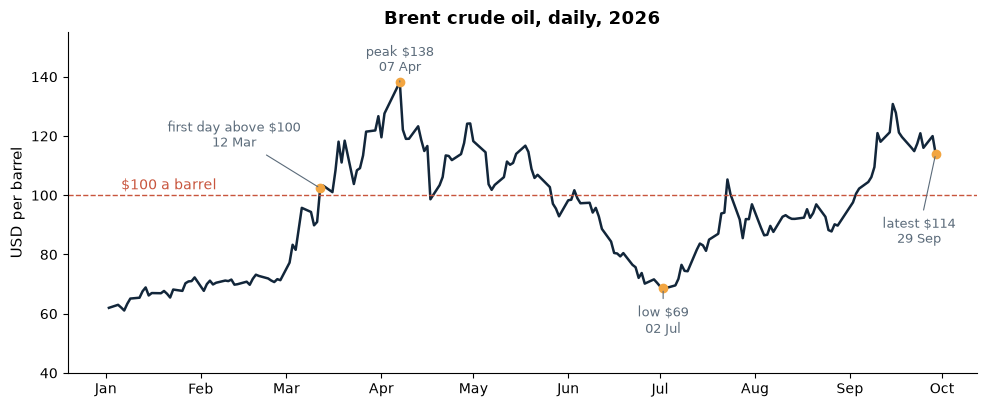

Monthly mean, USD per barrel:
date
Jan 2026     66.6
Feb 2026     70.9
Mar 2026    103.1
Apr 2026    117.3
May 2026    107.1
Jun 2026     85.4
Jul 2026     83.8
Aug 2026     91.1
Sep 2026    114.1

Five biggest one-day moves: {'17 Apr': '15.4%', '12 Mar': '12.5%', '23 Mar': '12.4%', '23 Jul': '11.9%', '08 Apr': '11.6%'}


In [31]:
p = b[b.date >= '2026-01-01'].dropna().set_index('date')['usd_per_barrel']
first_100 = p[p > 100].index.min()
peak_day, peak = p.idxmax(), p.max()
july_low_day = p['2026-06-15':'2026-07-31'].idxmin()
last_day, last = p.index.max(), p.iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(p.index, p.values, color=INK, lw=1.8)
ax.axhline(100, color=RUST, ls='--', lw=1)
ax.text(p.index[2], 102, '$100 a barrel', color=RUST, fontsize=10)
for day, val, label, dy, dx in [(first_100, p[first_100], f'first day above $100\n{first_100:%d %b}', 30, -62),
                            (peak_day, peak, f'peak ${peak:.0f}\n{peak_day:%d %b}', 8, 0),
                            (july_low_day, p[july_low_day], f'low ${p[july_low_day]:.0f}\n{july_low_day:%d %b}', -32, 0),
                            (last_day, last, f'latest ${last:.0f}\n{last_day:%d %b}', -64, -12)]:
    ax.annotate(label, (day, val), xytext=(dx, dy), textcoords='offset points', ha='center', fontsize=9, color=SLATE,
                arrowprops=dict(arrowstyle='-', color=SLATE, lw=0.8))
    ax.plot(day, val, 'o', color=AMBER, ms=6)
ax.set_ylabel('USD per barrel'); ax.set_title('Brent crude oil, daily, 2026')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')); ax.set_ylim(40, 155)
plt.tight_layout(); save(fig, 'brent_2026'); plt.show()
NUM.update(brent_first_100=f'{first_100:%d %b}', brent_peak=round(float(peak), 2), brent_peak_day=f'{peak_day:%d %b}', brent_low=round(float(p[july_low_day]), 1),
           brent_low_day=f'{july_low_day:%d %b}', brent_last=round(float(last), 2), brent_last_day=f'{last_day:%d %b}', brent_rows=int(len(b)), brent_missing=int(b.usd_per_barrel.isna().sum()),
           brent_days_over_100=int((p > 100).sum()), brent_jan_mean=round(float(p['2026-01'].mean()), 1))

monthly = p.resample('MS').mean().round(1)
monthly.index = monthly.index.strftime('%b %Y')
print('Monthly mean, USD per barrel:'); print(monthly.to_string())
big = p.pct_change().abs().sort_values(ascending=False).head(5)
print('\nFive biggest one-day moves:', {f'{d:%d %b}': f'{v:.1%}' for d, v in big.items()})

In [32]:
imf_rec=json.loads((DATA/'imf_provenance.json').read_text())
subprocess.run(['pdftotext','-layout',str(ROOT/imf_rec['file']),str(DERIVED/'imf_2026_text.txt')],check=True)
imf_txt=(DERIVED/'imf_2026_text.txt').read_text();imf_txt_flat=re.sub(r'\s+',' ',imf_txt)
flat_pages=[re.sub(r'\s+',' ',p) for p in imf_txt.split('\f')]
def extract_num(pattern):return float(re.search(pattern,imf_txt_flat).group(1))
NUM['imf']={
 'march_rise':extract_num(r'initial (\d+) percent price increase on March 7'),
 'unwind_petrol':extract_num(r'increases of (\d+) and \d+ percent for gasoline'),
 'unwind_diesel':extract_num(r'increases of \d+ and (\d+) percent for gasoline and diesel'),
 'diesel_levy_cut_rs':extract_num(r'temporary (\d+) Rs/L reduction in PDL on diesel'),
 'rupee_level':extract_num(r'around PRs (\d+) per dollar'),
 'q4_floor':extract_num(r'exceed (\d+) percent in Q4'),
 'fy27':extract_num(r'reach ([\d.]+) percent in FY27')}
locators={'fuel pricing':'Ex-refinery petroleum and diesel prices are benchmarked','March fuel':'After passing through an initial 20 percent','forecast':'CPI inflation is expected to exceed 10 percent in Q4','FX context':'After the Middle East war started'}
NUM['imf_pages']={key:next(i for i,p in enumerate(flat_pages,1) if text in p) for key,text in locators.items()}
print('IMF May 2026 report; physical page locators:',NUM['imf_pages']);display(pd.Series(NUM['imf']))


IMF May 2026 report; physical page locators: {'fuel pricing': 23, 'March fuel': 15, 'forecast': 16, 'FX context': 11}


march_rise             20.0
unwind_petrol          18.0
unwind_diesel          55.0
diesel_levy_cut_rs     80.0
rupee_level           280.0
q4_floor               10.0
fy27                    8.4
dtype: float64

In [33]:
EV = [('2026-02-28', 'Joint strikes begin (AP / Axios)'), ('2026-07-07', 'Renewed strikes / shipping attacks reported (AP / Axios)'), ('2026-09-07', 'Reuters report of weekend clashes: publication reference date')]
rows = []
for d, what in EV:
    day = pd.Timestamp(d)
    before, after = brent_d[:day - pd.Timedelta(days=1)], brent_d[day:]
    p0, p1, p5 = float(before.iloc[-1]), float(after.iloc[0]), float(after.iloc[4])
    rows.append({'date': day.strftime('%d %b'), 'event (as reported)': what, 'Brent just before': round(p0, 1),
                 '1st available quote on/after': f"{p1:.1f} ({100 * (p1 / p0 - 1):+.1f}%)", '5th available quote on/after': f"{p5:.1f} ({100 * (p5 / p0 - 1):+.1f}%)"})
    NUM.setdefault('war_events', []).append({'date': day.strftime('%d %b'), 'before': round(p0, 1), 'day1_pct': round(100 * (p1 / p0 - 1), 1), 'day5_pct': round(100 * (p5 / p0 - 1), 1), 'day5_price': round(p5, 1)})
pre = float(brent_d[:'2026-02-27'].iloc[-1])
NUM['war'] = {'pre_war': round(pre, 1), 'mar_mean': round(float(brent_d['2026-03'].mean()), 1), 'feb_mean': round(float(brent_d['2026-02'].mean()), 1),
              'mar_vs_feb_pct': round(100 * (float(brent_d['2026-03'].mean()) / float(brent_d['2026-02'].mean()) - 1), 0),
              'peak_2026': round(float(brent_d['2026'].max()), 2), 'peak_vs_prewar_pct': round(100 * (float(brent_d['2026'].max()) / pre - 1), 0)}
print(f"Last price before the strikes (27 Feb): ${pre:.1f}  |  2026 peak: ${NUM['war']['peak_2026']} ({NUM['war']['peak_vs_prewar_pct']:+.0f}% on pre-war)  |  March mean vs February mean: {NUM['war']['mar_vs_feb_pct']:+.0f}%")
pd.DataFrame(rows)

Last price before the strikes (27 Feb): $71.3  |  2026 peak: $138.21 (+94% on pre-war)  |  March mean vs February mean: +45%


,date,event (as reported),Brent just before,1st available quote on/after,5th available quote on/after
0,28 Feb,Joint strikes begin (AP / Axios),71.3,77.2 (+8.3%),95.7 (+34.2%)
1,07 Jul,Renewed strikes / shipping attacks reported (AP / Axios),69.6,71.8 (+3.2%),81.6 (+17.3%)
2,07 Sep,Reuters report of weekend clashes: publication reference date,102.2,104.5 (+2.2%),118.1 (+15.5%)


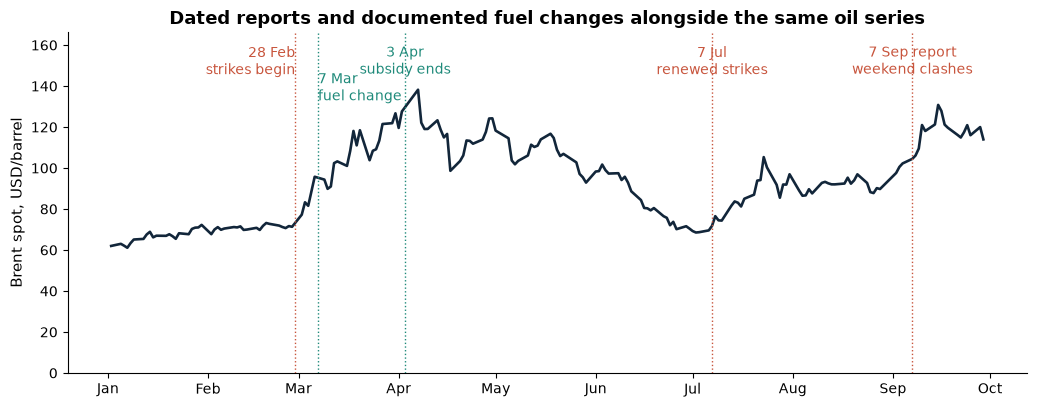

In [34]:
d26=brent_d['2026']
fig,ax=plt.subplots(figsize=(10.5,4.2))
ax.plot(d26.index,d26.values,color=INK,lw=1.9)
for date,label,color in [('2026-02-28','28 Feb\nstrikes begin',RUST),('2026-03-07','7 Mar\nfuel change',TEAL),('2026-04-03','3 Apr\nsubsidy ends',TEAL),('2026-07-07','7 Jul\nrenewed strikes',RUST),('2026-09-07','7 Sep report\nweekend clashes',RUST)]:
 ax.axvline(pd.Timestamp(date),color=color,ls=':',lw=1)
 yy=float(d26.max())+(22 if date=='2026-02-28' else 9 if date=='2026-03-07' else 22)
 ax.text(pd.Timestamp(date),yy,label,fontsize=10,ha='right' if date=='2026-02-28' else 'left' if date=='2026-03-07' else 'center',va='top',color=color)
ax.set_ylim(0,float(d26.max())+28);ax.set_ylabel('Brent spot, USD/barrel');ax.set_title('Dated reports and documented fuel changes alongside the same oil series')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'));plt.tight_layout();save(fig,'war_events_oil');plt.show()


In [35]:
# Observations vs forecast: report publication is May 2026, not March.
yoy_p=(g/g.shift(12)-1)*100
fy26=(g['2025-07':'2026-06'].mean()/g['2024-07':'2025-06'].mean()-1)*100
NUM['forecast']={'q4':float(yoy_p['2026-04':'2026-06'].mean()),'fy26':float(fy26),'jul_aug26':float(yoy_p['2026-07':'2026-08'].mean()),'imf_fy27':NUM['imf']['fy27']}
display(pd.DataFrame([
 {'statement':'May report: Apr–Jun FY26 Q4 expected above threshold','threshold':NUM['imf']['q4_floor'],'PBS observed mean YoY':NUM['forecast']['q4'],'limit':'May publication overlaps quarter; not a wholly out-of-sample forecast'},
 {'statement':'FY27 projection','threshold':NUM['imf']['fy27'],'PBS observed mean YoY':NUM['forecast']['jul_aug26'],'limit':'Only Jul–Aug; cannot validate full FY27 projection'}]))


,statement,threshold,PBS observed mean YoY,limit
0,May report: Apr–Jun FY26 Q4 expected above threshold,10.0,11.206602,May publication overlaps quarter; not a wholly out-of-sample forecast
1,FY27 projection,8.4,10.177573,Only Jul–Aug; cannot validate full FY27 projection


**Interpretation:** oil rose after reported conflict events; IMF staff describe domestic fuel changes and a relatively stable rupee around the reported level; PBS transport and headline inflation subsequently rise. This is consistent with an energy channel. It does not quantify oil→food pass-through, remove base effects or isolate causality. The full FY27 forecast cannot yet be checked.

## 9. Claim scoreboard — findings follow acquisition and audit
A measured input, arithmetic identity and observational timing deserve different verdicts. Every claim carries a source and a limit; no political winners/losers.

In [36]:
findings={
'I1':('SUPPORTED BY ARITHMETIC',NUM['iphone']['conclusion'],'Apple Newsroom / SBP; launch comparison CSV'),
'I2':('PARTLY SUPPORTED','FX is one input; USD base price and configuration also changed. Pakistan additions remain unverified.','Apple / SBP; iPhone rows'),
'A1':('NOT TESTABLE WITH CURRENT DATA','Exact apple threefold claim requires matched apple-specific prices; PBS measures fresh-fruit baskets.','PBS monthly PDFs; no matched apple price panel'),
'A2':('NOT ESTABLISHED','Local production does not establish insulation. Broad energy/transport/fruit changes do not identify apple cost shares.','PBS CPI/WPI; joint PDNA; no apple cost accounts'),
'P1':('NOT ESTABLISHED','Variables and policies can be documented; no causal contribution of one government is isolated.','N01/N02; World Bank; SBP; IMF / PID'),
'M1':('PARTLY SUPPORTED','Specific subsidy, tariff, revenue and FX commitments documented; aggregate inflation contribution not isolated.','N03/N04/N07/N08; IMF CR22/288; 2019 release; CR26/101'),
'F1':('SUPPORTED BY DIRECT MEASUREMENT',f"PID verifies petrol {old_price:.2f}→{new_price:.2f} Rs/litre effective 1 Mar 2022; {new_price-old_price:+.2f}. June reversal documented; no CPI share estimated.",'N05/N06; PID PR255; IMF CR22/288 MEFP ¶8(a)'),
'S1':('PARTLY SUPPORTED','Pandemic response and contemporaneous attribution documented; specific apple/iPhone price contribution not isolated.','SBP COVID page; N01; commodity/context series'),
'S2':('PARTLY SUPPORTED','Flood assessment documents food/agriculture/transport disruption; no apple-specific price coefficient.','N09/N10; joint official PDNA PDF'),
'W1':('CONSISTENT WITH OBSERVATIONAL TIMING','Conflict reporting, oil movements, documented fuel measures and later CPI movements align; causal pass-through shares not identified.','N11–N16; FRED/EIA; IMF CR26/101; PBS')}
slide_summaries={'I1': ('Apple / SBP: calculated floor rose', 'Entry storage changes; pre-tax benchmark only'), 'I2': ('Apple: dollar price also changed', 'Exact Pakistan additions unverified'), 'A1': ('PBS: fresh-fruit baskets', 'No matched apple-specific price panel'), 'A2': ('PBS: food, energy, transport moved', 'No apple cost accounts or causal shares'), 'P1': ('News / WB / SBP: overlapping changes', 'No counterfactual or political blame share'), 'M1': ('IMF: subsidy, tariff, tax, FX clauses', 'Commitment ≠ implementation ≠ CPI effect'), 'F1': ('PID: official petrol-price reduction', 'Direct price change ≠ contribution to CPI'), 'S1': ('SBP / news: pandemic response documented', 'Product-specific contribution not isolated'), 'S2': ('Joint PDNA / news: supply damage', 'Aggregate assessment ≠ apple-price effect'), 'W1': ('FRED / IMF / PBS: timing aligns', 'No identified oil→food causal share')}
matrix['slide_evidence']=matrix.claim_id.map(lambda k:slide_summaries[k][0])
matrix['slide_limit']=matrix.claim_id.map(lambda k:slide_summaries[k][1])
matrix['confidence_category']=matrix.claim_id.map(lambda k:findings[k][0])
matrix['finding']=matrix.claim_id.map(lambda k:findings[k][1])
matrix['actual_source']=matrix.claim_id.map(lambda k:findings[k][2])
matrix['evidence_date']='source cut-off 2026-10-01; publication/measurement dates in primary_source_catalog.json and public_claims.json'
matrix['source_catalogue']='data/v2/primary_source_catalog.json'
matrix.to_json(DERIVED/'source_evidence_matrix.json',orient='records',indent=2)
matrix.to_csv(DERIVED/'source_evidence_matrix.csv',index=False)
NUM['scoreboard']=matrix.to_dict('records')
display(matrix[['claim_id','claim','actual_source','measurement_period','finding','confidence_category','data_quality_limitations']])


,claim_id,claim,actual_source,measurement_period,finding,confidence_category,data_quality_limitations
0,I1,Rupee depreciation raised the imported iPhone floor,Apple Newsroom / SBP; launch comparison CSV,"2019, 2021, 2023, 2026 availability dates",2019→2026: US base price +18.2%; PKR/USD +77.6%; pre-tax floor +110.0%. 2023...,SUPPORTED BY ARITHMETIC,Entry tiers change storage; pre-tax benchmark is not observed Pakistan retail
1,I2,An imported iPhone should track the exchange rate alone,Apple / SBP; iPhone rows,same four launch periods,FX is one input; USD base price and configuration also changed. Pakistan add...,PARTLY SUPPORTED,No constant-quality adjustment or verified current Pakistan tax schedule
2,A1,Apples rose exactly from Rs100/kg to Rs300/kg,PBS monthly PDFs; no matched apple price panel,opening observation has unspecified dates,Exact apple threefold claim requires matched apple-specific prices; PBS meas...,NOT TESTABLE WITH CURRENT DATA,PBS fresh-fruit basket is not apples
3,A2,Local produce is insulated from oil / FX,PBS CPI/WPI; joint PDNA; no apple cost accounts,Jul 2022–Sep 2026,Local production does not establish insulation. Broad energy/transport/fruit...,NOT ESTABLISHED,No apple cost accounts; wholesale and retail baskets differ
4,P1,Policy explains the whole inflation rise during PTI period,N01/N02; World Bank; SBP; IMF / PID,2018–2022; 2023 is after PTI period,Variables and policies can be documented; no causal contribution of one gove...,NOT ESTABLISHED,Calendar annual values straddle government changes; observational data canno...
5,M1,IMF-linked programme policies contributed through specific channels,N03/N04/N07/N08; IMF CR22/288; 2019 release; CR26/101,2019 EFF; 2022 review; May 2026 report,"Specific subsidy, tariff, revenue and FX commitments documented; aggregate i...",PARTLY SUPPORTED,Documented commitments differ from implementation and causal estimates
6,F1,Government fuel/subsidy decisions changed administered prices,N05/N06; PID PR255; IMF CR22/288 MEFP ¶8(a),28 Feb announcement / 1 Mar 2022 effect; June reversal,PID verifies petrol 159.86→149.86 Rs/litre effective 1 Mar 2022; -10.00. Jun...,SUPPORTED BY DIRECT MEASUREMENT,Direct fuel-price arithmetic does not measure contribution to all CPI
7,S1,COVID and supply disruptions contributed,SBP COVID page; N01; commodity/context series,2020–2021,Pandemic response and contemporaneous attribution documented; specific apple...,PARTLY SUPPORTED,COVID timing and official response documented; apple-specific effect not ide...
8,S2,Floods disrupted domestic food supply,N09/N10; joint official PDNA PDF,Jun–Oct 2022 assessment,Flood assessment documents food/agriculture/transport disruption; no apple-s...,PARTLY SUPPORTED,Assessed aggregate damage is not an apple-price causal coefficient
9,W1,2026 conflict passed through oil→fuel→transport→food,N11–N16; FRED/EIA; IMF CR26/101; PBS,"Feb–Sep 2026; feed through Aug, PDF Sep","Conflict reporting, oil movements, documented fuel measures and later CPI mo...",CONSISTENT WITH OBSERVATIONAL TIMING,Event windows descriptive; no counterfactual; separate months and YoY base e...


## 10. So why?
**Imported iPhone:** foreign starting price × PKR/USD gives a reproducible pre-tax benchmark; domestic additions require their own official evidence. **Local apple:** baskets, broad costs and supply disruption matter as evidence classes, but do not prove an exact apple-specific history or margins. **Periods:** earlier years combined global, currency, policy and domestic shocks; 2026 timing is consistent with an oil/energy channel while the rupee is reported relatively stable. **Politics:** document decisions and attribute public explanations; stop before assigning the whole inflation episode to a government, institution or event.

Different claims require different evidence. Where did it come from? Is it current? What does it measure? Can we reproduce it? What are we allowed to conclude?

## 11. Responsible automated access and browser demo
Use API/file/feed before HTML/browser when suitable and permitted. Check terms/robots; identify the client; pace/cache requests; respect 429/403; never bypass authentication, CAPTCHA or blocks. Store allowed metadata/short summaries, not full copyrighted news articles. Keep credentials out of logs.

The existing bookshop demo illustrates browser acquisition, pagination, raw snapshot, provenance, encoding and expected rows. Normal execution reads saved demo outputs; live browser collection is a separate intentional demonstration.

In [37]:
bk = pd.read_csv(DATA / 'books_raw_scraped.csv')
print(repr(bk.price_text.iloc[0]), '  <- what requests guessed (ISO-8859-1)')
print(repr(bk.price_text.str.encode('latin-1').str.decode('utf-8').iloc[0]), '  <- repaired as UTF-8')
demo = ROOT / 'demo_output'
if (demo / 'books_catalogue.csv').exists():
    cat = pd.read_csv(demo / 'books_catalogue.csv')
    print(f'\nBrowser demo output: {len(cat)} books x {cat.shape[1]} columns')
    print((demo / 'quality_report.txt').read_text().split('books per category')[0])
else:
    print('\nRun `python demo_browser.py` first.')

'Â£51.77'   <- what requests guessed (ISO-8859-1)
'£51.77'   <- repaired as UTF-8

Browser demo output: 24 books x 17 columns
QUALITY REPORT: books_catalogue.csv
rows: 24   columns: 17

[uniqueness]   duplicate UPCs:                    0
[uniqueness]   duplicate titles:                  0
[completeness] books with no description:         0
[completeness] missing values (other columns):    0
[consistency]  excl. tax + tax != incl. tax:      0
[consistency]  price_gbp != price incl. tax:      0
[validity]     price <= 0 or > 100:               0
[validity]     rating outside 1-5:                0
[validity]     in stock but stock_count == 0:     0
[validity]     distinct product types:            ['Books']
[validity]     distinct tax values:               [0.0]  <- every book taxed 0?
[validity]     books with 0 reviews:              24 of 24  <- is the field used?
[range]        price: min 10.69  median 40.72  max 57.31




## 12. Assignment 1
The full specification is [Assignment 1: Acquire a dataset and audit whether it can be trusted](../../assignments/assignment-01/README.md), with an optional starter kit beside it. Main report **at most 5 pages**; **≥8 explicit checks across all six dimensions**; detect **missing rows as well as missing values**; save raw snapshots, provenance and SHA-256; produce **Fit / Fit with caveats / Not fit** plus a specific **refused claim**; code must reproduce offline. News is an acquisition/source-quality option, not NLP.

Final synthesis: question → source map → acquire → preserve → audit → reconcile → calculate → defensible finding or explicit refusal.